# Enriched Method 1 - xG with StatsBomb remote shot features

This notebook keeps the same high-level Method 1 xG experiment: train one xG
model on men data, train one xG model on women training data, score the same
women test shots with both models, then compare player rankings.

The project `.venv` is preconfigured with the needed packages. All data loading
uses remote StatsBomb Open Data through `statsbombpy`. The xG model uses
distance, angle, body part, shot technique, shot type, play pattern / set-piece
context, under-pressure flag, and first-time flag.


## 1. Imports and constants

In [1]:
import os
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from statsbombpy import sb
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

DATA_DIR = Path("data")
CACHE_DIR = Path("vaep_data")
DATA_DIR.mkdir(exist_ok=True)
CACHE_DIR.mkdir(exist_ok=True)

print("ready")


ready


## 2. Competition lists

Women: 2023/24 top leagues plus 2023 NWSL. Men: 2015/16 top-4 complete leagues.

In [2]:
WOMEN_COMPETITIONS = [
    (37, 281, "WSL"),
    (135, 281, "Frauen Bundesliga"),
    (182, 281, "Liga F"),
    (131, 281, "Serie A Women"),
    (49, 107, "NWSL"),
]
MEN_COMPETITIONS = [
    (11, 27, "La Liga"),
    (2, 27, "Premier League"),
    (12, 27, "Serie A"),
    (7, 27, "Ligue 1"),
]


## 3. Load remote match lists (cached)

In [3]:
def load_remote_matches(competitions, cache_tag):
    """Load remote StatsBomb match lists for a set of competitions."""
    matches_cache = CACHE_DIR / f"{cache_tag}_matches_statsbombpy_remote.pkl"
    if matches_cache.exists():
        print(f"[cache] {cache_tag} matches")
        return pd.read_pickle(matches_cache)

    match_frames = []
    for competition_id, season_id, league_name in competitions:
        try:
            matches = sb.matches(competition_id=competition_id, season_id=season_id)
        except Exception as error:
            print("  !", league_name, error)
            continue

        matches = matches.copy()
        matches["league"] = league_name
        match_frames.append(matches)
        print(f"[load matches] {league_name}: {len(matches)} games")

    all_matches = pd.concat(match_frames, ignore_index=True)
    all_matches.to_pickle(matches_cache)
    return all_matches


women_matches = load_remote_matches(WOMEN_COMPETITIONS, "women")
men_matches = load_remote_matches(MEN_COMPETITIONS, "men2015")

print("women games", len(women_matches), "men games", len(men_matches))


[cache] women matches
[cache] men2015 matches
women games 771 men games 1517


## 4. Shared setup: women test split and player filters

The two xG models are compared on the same held-out women games.

In [4]:
random_generator = np.random.default_rng(42)
women_game_ids = women_matches["match_id"].unique()

WOMEN_TEST_GAMES = set(
    random_generator.choice(
        women_game_ids,
        size=int(len(women_game_ids) * 0.30),
        replace=False,
    )
)
print("women test games:", len(WOMEN_TEST_GAMES), "of", len(women_game_ids))

MIN_SHOTS_PER_PLAYER = 10
MIN_ACTIONS_PER_PLAYER = 100


women test games: 231 of 771


## 5. Shot metadata helpers

In [5]:
def is_missing_value(value):
    """Treat None/NaN/pandas missing scalars as missing, but leave lists/dicts alone."""
    if value is None:
        return True
    try:
        missing = pd.isna(value)
    except (TypeError, ValueError):
        return False
    if isinstance(missing, (bool, np.bool_)):
        return bool(missing)
    return False


def statsbomb_name(value):
    """Return the StatsBomb object name, or the value itself if it is already flat."""
    if isinstance(value, dict):
        return value.get("name")
    return None if is_missing_value(value) else value


def first_available_value(row, column_names, default=None):
    """Return the first non-missing value among candidate dataframe columns."""
    for column_name in column_names:
        if column_name in row.index:
            value = row[column_name]
            if not is_missing_value(value):
                return value
    return default


def shot_coordinates(row):
    """Extract StatsBomb shot x/y coordinates from either a list or flattened columns."""
    location = first_available_value(row, ["location"])
    if isinstance(location, (list, tuple, np.ndarray)) and len(location) >= 2:
        return location[0], location[1]

    return (
        first_available_value(row, ["location_x", "x", "start_x"], np.nan),
        first_available_value(row, ["location_y", "y", "start_y"], np.nan),
    )


def distance_and_angle_from_statsbomb_coordinates(shot_x, shot_y):
    """Compute distance/angle from StatsBomb 120x80 coordinates."""
    spadl_x = shot_x * 105 / 120
    spadl_y = shot_y * 68 / 80
    dx = 105 - spadl_x
    dy = 34 - spadl_y

    distance = np.hypot(dx, dy)
    angle = abs(np.arctan2(7.32 * dx, dx**2 + dy**2 - (7.32 / 2) ** 2))
    return distance, angle


def shot_context(shot_type, play_pattern):
    """Collapse shot.type + play_pattern into open play / FK / penalty / set-piece context."""
    if shot_type == "Penalty":
        return "Penalty"
    if shot_type == "Free Kick" or play_pattern == "From Free Kick":
        return "Free Kick"
    if play_pattern in {"From Corner", "From Throw In", "From Keeper", "From Goal Kick", "From Kick Off"}:
        return "Set Piece"
    if shot_type == "Open Play" or play_pattern == "Regular Play":
        return "Open Play"
    return "Other"


def boolean_flag(value):
    """Convert optional StatsBomb boolean fields to clean booleans."""
    return False if is_missing_value(value) else bool(value)


def event_to_xg_row(event, match_id, league_name):
    """Convert one remote StatsBomb shot event into one xG modeling row."""
    shot_x, shot_y = shot_coordinates(event)
    distance, angle = distance_and_angle_from_statsbomb_coordinates(shot_x, shot_y)

    shot_type = statsbomb_name(first_available_value(event, ["shot_type"], "Unknown"))
    play_pattern = statsbomb_name(first_available_value(event, ["play_pattern"], "Unknown"))
    body_part = statsbomb_name(first_available_value(event, ["shot_body_part"], "Unknown"))
    technique = statsbomb_name(first_available_value(event, ["shot_technique"], "Unknown"))
    outcome = statsbomb_name(first_available_value(event, ["shot_outcome"], "Unknown"))
    statsbomb_xg = first_available_value(event, ["shot_statsbomb_xg"], np.nan)

    return {
        "game_id": match_id,
        "player_id": first_available_value(event, ["player_id"]),
        "league": league_name,
        "shot_x": shot_x,
        "shot_y": shot_y,
        "distance": distance,
        "angle": angle,
        "body_part": body_part or "Unknown",
        "shot_technique": technique or "Unknown",
        "shot_type": shot_type or "Unknown",
        "play_pattern": play_pattern or "Unknown",
        "shot_context": shot_context(shot_type, play_pattern),
        "under_pressure": boolean_flag(first_available_value(event, ["under_pressure"], False)),
        "first_time": boolean_flag(first_available_value(event, ["shot_first_time"], False)),
        "statsbomb_xg": np.nan if is_missing_value(statsbomb_xg) else float(statsbomb_xg),
        "goal": int(outcome == "Goal"),
    }


## 6. Load enriched shot tables from remote StatsBomb data

This cell downloads events through `statsbombpy`, extracts shot rows, and caches
the resulting shot tables. For women games, it also caches position rows so we
can exclude goalkeepers later.

In [6]:
def remote_shot_events(events):
    """Filter a StatsBomb events dataframe down to shot events."""
    if "type" not in events.columns:
        return pd.DataFrame()
    return events[events["type"].eq("Shot")].copy()


def event_positions(events):
    """Extract player-position observations from an events dataframe."""
    required_columns = {"player_id", "position"}
    if not required_columns.issubset(events.columns):
        return pd.DataFrame(columns=["player_id", "position_name"])

    return (
        events[["player_id", "position"]]
        .dropna()
        .rename(columns={"position": "position_name"})
    )


def load_remote_xg_shots(matches, cache_tag, collect_positions=False):
    """Load remote StatsBomb shots with enriched xG features."""
    shots_cache = CACHE_DIR / f"{cache_tag}_xg_shots_statsbombpy_remote.pkl"
    positions_cache = CACHE_DIR / f"{cache_tag}_positions_statsbombpy_remote.pkl"

    required_shot_columns = {"statsbomb_xg"}
    if shots_cache.exists() and (not collect_positions or positions_cache.exists()):
        shots = pd.read_pickle(shots_cache)
        missing_columns = required_shot_columns - set(shots.columns)
        if not missing_columns:
            print(f"[cache] {cache_tag} remote xG shots")
            if collect_positions:
                return shots, pd.read_pickle(positions_cache)
            return shots
        print(f"[cache] {cache_tag} missing {sorted(missing_columns)}; rebuilding")

    shot_rows = []
    position_frames = []

    for processed_count, match in enumerate(matches.itertuples(index=False), start=1):
        match_id = int(match.match_id)
        league_name = match.league

        try:
            events = sb.events(match_id=match_id)
        except Exception:
            continue

        if collect_positions:
            position_frames.append(event_positions(events))

        for _, shot_event in remote_shot_events(events).iterrows():
            shot_rows.append(event_to_xg_row(shot_event, match_id, league_name))

        if processed_count % 50 == 0:
            print(f"  processed {processed_count:,} / {len(matches):,} matches for {cache_tag}")

    shots = pd.DataFrame(shot_rows)
    shots.to_pickle(shots_cache)
    print(f"[cache] wrote {cache_tag} remote xG shots: {len(shots):,} shots")

    if collect_positions:
        positions = (
            pd.concat(position_frames, ignore_index=True)
            if position_frames
            else pd.DataFrame(columns=["player_id", "position_name"])
        )
        positions.to_pickle(positions_cache)
        return shots, positions

    return shots


women_shots, women_positions = load_remote_xg_shots(
    women_matches,
    "women",
    collect_positions=True,
)
men_shots = load_remote_xg_shots(men_matches, "men2015")

women_train_shots = women_shots[~women_shots.game_id.isin(WOMEN_TEST_GAMES)].copy()
women_test_shots = women_shots[women_shots.game_id.isin(WOMEN_TEST_GAMES)].copy()

print(
    f"xG samples | men train={len(men_shots):,} "
    f"women train={len(women_train_shots):,} women test={len(women_test_shots):,}"
)


[cache] women missing ['statsbomb_xg']; rebuilding
  processed 50 / 771 matches for women
  processed 100 / 771 matches for women
  processed 150 / 771 matches for women
  processed 200 / 771 matches for women
  processed 250 / 771 matches for women
  processed 300 / 771 matches for women
  processed 350 / 771 matches for women
  processed 400 / 771 matches for women
  processed 450 / 771 matches for women
  processed 500 / 771 matches for women
  processed 550 / 771 matches for women
  processed 600 / 771 matches for women
  processed 650 / 771 matches for women
  processed 700 / 771 matches for women
  processed 750 / 771 matches for women
[cache] wrote women remote xG shots: 20,259 shots
[cache] men2015 missing ['statsbomb_xg']; rebuilding
  processed 50 / 1,517 matches for men2015
  processed 100 / 1,517 matches for men2015
  processed 150 / 1,517 matches for men2015
  processed 200 / 1,517 matches for men2015
  processed 250 / 1,517 matches for men2015
  processed 300 / 1,517 matc

## 7. Goalkeeper map

In [7]:
player_primary_position = (
    women_positions.groupby("player_id")["position_name"]
    .agg(lambda positions: positions.value_counts().index[0])
    .to_dict()
    if len(women_positions)
    else {}
)


def is_goalkeeper(player_id):
    return "Goalkeeper" in str(player_primary_position.get(player_id, ""))


print(
    "positions mapped:",
    len(player_primary_position),
    "| GKs:",
    sum("Goalkeeper" in str(position) for position in player_primary_position.values()),
)



positions mapped: 1533 | GKs: 138


## 8. Build model matrices

Categorical StatsBomb fields are one-hot encoded. We build one shared feature
schema from both training populations, then use that same schema for men train,
women train, and women test. This ensures the men-trained and women-trained xG
models receive exactly the same columns when scoring the women test shots.

In [8]:
NUMERIC_XG_FEATURES = ["distance", "angle"]
BOOLEAN_XG_FEATURES = ["under_pressure", "first_time"]
CATEGORICAL_XG_FEATURES = [
    "body_part",
    "shot_technique",
    "shot_type",
    "play_pattern",
    "shot_context",
]
XG_BASE_FEATURES = NUMERIC_XG_FEATURES + BOOLEAN_XG_FEATURES + CATEGORICAL_XG_FEATURES


def build_xg_design_matrix(shots, expected_columns=None):
    """Turn shot rows into the numeric matrix expected by XGBoost."""
    features = shots[XG_BASE_FEATURES].copy()

    for column in NUMERIC_XG_FEATURES:
        features[column] = pd.to_numeric(features[column], errors="coerce").fillna(0)
    for column in BOOLEAN_XG_FEATURES:
        features[column] = features[column].fillna(False).astype(int)
    for column in CATEGORICAL_XG_FEATURES:
        features[column] = features[column].fillna("Unknown").astype(str)

    features = pd.get_dummies(features, columns=CATEGORICAL_XG_FEATURES, dtype=float)
    if expected_columns is not None:
        features = features.reindex(columns=expected_columns, fill_value=0)
    return features


# Use one shared feature schema for both models.
# The schema is learned from training data only: men training shots + women training shots.
training_shots_for_feature_schema = pd.concat(
    [men_shots, women_train_shots],
    ignore_index=True,
)
xg_feature_columns = build_xg_design_matrix(training_shots_for_feature_schema).columns

men_train_features = build_xg_design_matrix(
    men_shots,
    expected_columns=xg_feature_columns,
)
women_train_features = build_xg_design_matrix(
    women_train_shots,
    expected_columns=xg_feature_columns,
)
women_test_features = build_xg_design_matrix(
    women_test_shots,
    expected_columns=xg_feature_columns,
)

print("xG base features:", XG_BASE_FEATURES)
print("shared one-hot model columns:", len(xg_feature_columns))
print(
    "feature matrix shapes | "
    f"men_train={men_train_features.shape} "
    f"women_train={women_train_features.shape} "
    f"women_test={women_test_features.shape}"
)


xG base features: ['distance', 'angle', 'under_pressure', 'first_time', 'body_part', 'shot_technique', 'shot_type', 'play_pattern', 'shot_context']
shared one-hot model columns: 33
feature matrix shapes | men_train=(37888, 33) women_train=(14176, 33) women_test=(6083, 33)


## 9. Train xG models and compare player rankings

The men-trained model and women-trained model both score the same women test
shots. Player-level xG totals are then compared with Spearman correlation.

In [9]:
men_xg_model = XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    random_state=42,
).fit(men_train_features, men_shots["goal"])

women_xg_model = XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    random_state=42,
).fit(women_train_features, women_train_shots["goal"])

xg_predictions = women_test_shots.copy()
xg_predictions["men_model_xg"] = men_xg_model.predict_proba(women_test_features)[:, 1]
xg_predictions["women_model_xg"] = women_xg_model.predict_proba(women_test_features)[:, 1]

player_xg_comparison = (
    xg_predictions.groupby("player_id")
    .agg(
        m=("men_model_xg", "sum"),
        w=("women_model_xg", "sum"),
        n=("men_model_xg", "size"),
    )
    .reset_index()
)
player_xg_comparison = player_xg_comparison[
    (player_xg_comparison.n >= MIN_SHOTS_PER_PLAYER)
    & (~player_xg_comparison.player_id.map(is_goalkeeper))
]

rho_xg = stats.spearmanr(player_xg_comparison.m, player_xg_comparison.w)[0]


print(f"xG  | players={len(player_xg_comparison)}  Spearman={rho_xg:.3f}")


xG  | players=189  Spearman=0.988


## 10. Compare trained xG models with StatsBomb xG

This diagnostic compares the two xG models we trained against StatsBomb's built-in
`shot_statsbomb_xg` on the same women test shots.

,source,shots,total_xg,mean_xg,mae_vs_statsbomb_xg,rmse_vs_statsbomb_xg,pearson_vs_statsbomb_xg,spearman_vs_statsbomb_xg,brier_vs_goal
0,men_trained_model,6083,725.8505,0.1193,0.0404,0.0715,0.8709,0.8980,0.0792
1,women_trained_model,6083,697.1903,0.1146,0.0401,0.0716,0.8655,0.8701,0.0793
2,statsbomb_xg,6083,646.6034,0.1063,0.0000,0.0000,1.0000,1.0000,0.0752


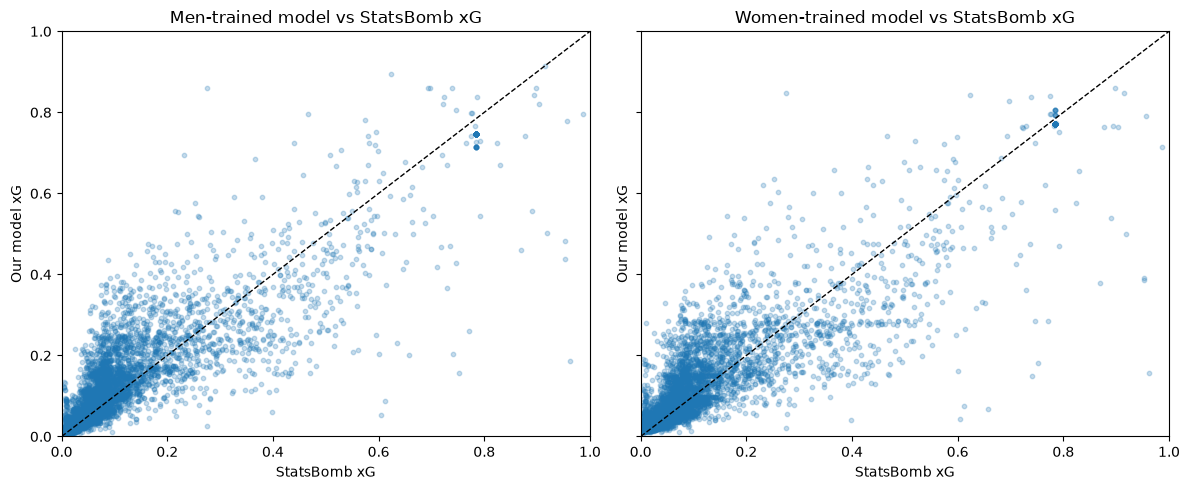

In [10]:
if "statsbomb_xg" not in xg_predictions.columns:
    raise ValueError(
        "xg_predictions does not include statsbomb_xg. "
        "Re-run the shot-loading cell so the xG shot cache is rebuilt with shot_statsbomb_xg."
    )

statsbomb_comparison_shots = xg_predictions.dropna(subset=["statsbomb_xg"]).copy()
if statsbomb_comparison_shots.empty:
    raise ValueError("No non-missing StatsBomb xG values found in the women test shots.")

prediction_columns = {
    "men_trained_model": "men_model_xg",
    "women_trained_model": "women_model_xg",
    "statsbomb_xg": "statsbomb_xg",
}

comparison_rows = []
for label, column in prediction_columns.items():
    prediction = statsbomb_comparison_shots[column]
    statsbomb_xg = statsbomb_comparison_shots["statsbomb_xg"]
    goals = statsbomb_comparison_shots["goal"]

    comparison_rows.append({
        "source": label,
        "shots": len(statsbomb_comparison_shots),
        "total_xg": prediction.sum(),
        "mean_xg": prediction.mean(),
        "mae_vs_statsbomb_xg": np.mean(np.abs(prediction - statsbomb_xg)),
        "rmse_vs_statsbomb_xg": np.sqrt(np.mean((prediction - statsbomb_xg) ** 2)),
        "pearson_vs_statsbomb_xg": prediction.corr(statsbomb_xg, method="pearson"),
        "spearman_vs_statsbomb_xg": prediction.corr(statsbomb_xg, method="spearman"),
        "brier_vs_goal": np.mean((prediction - goals) ** 2),
    })

model_vs_statsbomb_xg = pd.DataFrame(comparison_rows)
display(model_vs_statsbomb_xg.round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
plot_columns = [
    ("men_model_xg", "Men-trained model vs StatsBomb xG"),
    ("women_model_xg", "Women-trained model vs StatsBomb xG"),
]

max_xg = statsbomb_comparison_shots[["statsbomb_xg", "men_model_xg", "women_model_xg"]].max().max()
axis_limit = min(1.0, max_xg * 1.05)

for axis, (column, title) in zip(axes, plot_columns):
    axis.scatter(
        statsbomb_comparison_shots["statsbomb_xg"],
        statsbomb_comparison_shots[column],
        alpha=0.25,
        s=10,
    )
    axis.plot([0, axis_limit], [0, axis_limit], linestyle="--", color="black", linewidth=1)
    axis.set_title(title)
    axis.set_xlabel("StatsBomb xG")
    axis.set_ylabel("Our model xG")
    axis.set_xlim(0, axis_limit)
    axis.set_ylim(0, axis_limit)

plt.tight_layout()
plt.show()


## 11. Inspect raw `statsbombpy` outputs

This optional diagnostic cell shows what `sb.matches(...)` and `sb.events(...)`
return before we transform them into xG features.

In [11]:
# Pick one already-loaded women match so this cell is reproducible with the notebook state.
example_match = women_matches.iloc[0]
example_match_id = int(example_match.match_id)
example_league = example_match.league

print(f"Example match: {example_match_id} | {example_league}")

# 1) What does sb.matches(...) return?
example_matches = sb.matches(
    competition_id=int(example_match.competition_id),
    season_id=int(example_match.season_id),
)
print("\nsb.matches(...) shape:", example_matches.shape)
print("sb.matches(...) columns:")
print(example_matches.columns.tolist())

print("\nOne sb.matches(...) row:")
display(example_matches.head(1).T.rename(columns={example_matches.index[0]: "value"}))

# 2) What does sb.events(...) return?
example_events = sb.events(match_id=example_match_id)
print("\nsb.events(...) shape:", example_events.shape)
print("sb.events(...) columns:")
print(example_events.columns.tolist())

print("\nEvent type counts:")
display(example_events["type"].value_counts().rename_axis("type").reset_index(name="n"))

# 3) Show raw shot rows before our xG feature extraction.
example_shots = example_events[example_events["type"].eq("Shot")].copy()
shot_debug_columns = [
    "minute",
    "second",
    "team",
    "player",
    "player_id",
    "position",
    "location",
    "play_pattern",
    "shot_type",
    "shot_body_part",
    "shot_technique",
    "shot_first_time",
    "under_pressure",
    "shot_outcome",
    "shot_statsbomb_xg",
]
shot_debug_columns = [column for column in shot_debug_columns if column in example_shots.columns]

print("\nRaw shot rows from sb.events(...):")
display(example_shots[shot_debug_columns].head(10))

print("\nRaw shot rows after event_to_xg_row(...):")
example_xg_rows = pd.DataFrame(
    [event_to_xg_row(shot_event, example_match_id, example_league) for _, shot_event in example_shots.head(10).iterrows()]
)
display(example_xg_rows)


Example match: 3913082 | WSL

sb.matches(...) shape: (132, 55)
sb.matches(...) columns:
['match_id', 'match_date', 'kick_off', 'home_score', 'away_score', 'match_status', 'match_status_360', 'last_updated', 'last_updated_360', 'match_week', 'competition_id', 'competition_country_name', 'competition_name', 'competition', 'season_id', 'season', 'home_team_id', 'home_team', 'home_team_gender', 'home_team_group', 'home_team_country_id', 'home_team_country_name', 'away_team_id', 'away_team', 'away_team_gender', 'away_team_group', 'away_team_country_id', 'away_team_country_name', 'competition_stage_id', 'competition_stage', 'stadium_id', 'stadium', 'stadium_country_id', 'stadium_country_name', 'referee_id', 'referee', 'referee_country_id', 'referee_country_name', 'home_managers', 'away_managers', 'home_manager_id', 'home_manager_name', 'home_manager_nickname', 'home_manager_dob', 'home_manager_country_id', 'home_manager_country_name', 'away_manager_id', 'away_manager_name', 'away_manager_nic

,value
match_id,3913082
match_date,2023-11-05
kick_off,18:45:00.000
home_score,2
away_score,2
match_status,available
match_status_360,unscheduled
last_updated,2026-04-11T13:03:17.779673
last_updated_360,None
match_week,5



sb.events(...) shape: (3309, 94)
sb.events(...) columns:
['50_50', 'bad_behaviour_card', 'ball_receipt_outcome', 'ball_recovery_offensive', 'ball_recovery_recovery_failure', 'block_offensive', 'carry_end_location', 'clearance_aerial_won', 'clearance_body_part', 'clearance_head', 'clearance_left_foot', 'clearance_right_foot', 'counterpress', 'dribble_nutmeg', 'dribble_outcome', 'dribble_overrun', 'duel_outcome', 'duel_type', 'duration', 'foul_committed_advantage', 'foul_committed_card', 'foul_committed_type', 'foul_won_advantage', 'foul_won_defensive', 'goalkeeper_body_part', 'goalkeeper_end_location', 'goalkeeper_outcome', 'goalkeeper_position', 'goalkeeper_shot_saved_to_post', 'goalkeeper_technique', 'goalkeeper_type', 'id', 'index', 'injury_stoppage_in_chain', 'interception_outcome', 'location', 'match_id', 'minute', 'off_camera', 'out', 'pass_aerial_won', 'pass_angle', 'pass_assisted_shot_id', 'pass_body_part', 'pass_cross', 'pass_cut_back', 'pass_deflected', 'pass_end_location', '

,type,n
0,Pass,898
1,Ball Receipt*,848
2,Carry,691
3,Pressure,311
4,Ball Recovery,117
5,Duel,73
6,Clearance,58
7,Goal Keeper,42
8,Block,40
9,Miscontrol,37



Raw shot rows from sb.events(...):


,minute,second,team,player,player_id,position,location,play_pattern,shot_type,shot_body_part,shot_technique,shot_first_time,under_pressure,shot_outcome,shot_statsbomb_xg
2988,0,54,Manchester United W,Leah Galton,31539.0,Left Wing,"[112.1, 36.3]",From Kick Off,Open Play,Head,Normal,NaN,True,Blocked,0.080485
2989,2,29,Manchester United W,Ella Toone,31534.0,Left Center Midfield,"[103.2, 34.0]",From Throw In,Open Play,Right Foot,Normal,NaN,NaN,Blocked,0.032564
2990,2,32,Manchester United W,Hinata Miyazawa,401932.0,Right Center Midfield,"[97.4, 44.4]",From Throw In,Open Play,Right Foot,Normal,NaN,NaN,Blocked,0.039369
2991,2,33,Manchester United W,Melvine Malard,31614.0,Right Wing,"[107.7, 38.8]",From Throw In,Open Play,Left Foot,Normal,True,True,Saved,0.269035
2992,7,12,Manchester United W,Geyse da Silva Ferreira,25543.0,Center Forward,"[115.5, 53.9]",Regular Play,Open Play,Right Foot,Normal,NaN,NaN,Off T,0.015162
2993,18,1,Brighton & Hove Albion WFC,Madison Haley,405188.0,Right Wing,"[114.9, 42.6]",From Corner,Open Play,Head,Normal,NaN,True,Blocked,0.124237
2994,18,15,Brighton & Hove Albion WFC,Elisabeth Terland,276301.0,Center Forward,"[105.7, 42.2]",From Corner,Open Play,Right Foot,Normal,True,NaN,Saved,0.108810
2995,20,18,Brighton & Hove Albion WFC,Jorelyn Andrea Daniela Carabalí Martínez,388473.0,Left Center Back,"[111.5, 37.3]",From Corner,Open Play,Head,Normal,NaN,True,Saved,0.065711
2996,27,48,Brighton & Hove Albion WFC,Elisabeth Terland,276301.0,Center Forward,"[102.8, 31.3]",From Free Kick,Open Play,Right Foot,Half Volley,True,NaN,Off T,0.086174
2997,29,25,Brighton & Hove Albion WFC,Maisie Symonds,85004.0,Left Defensive Midfield,"[101.5, 52.6]",From Counter,Open Play,Right Foot,Normal,NaN,NaN,Wayward,0.042489



Raw shot rows after event_to_xg_row(...):


,game_id,player_id,league,shot_x,shot_y,distance,angle,body_part,shot_technique,shot_type,play_pattern,shot_context,under_pressure,first_time,statsbomb_xg,goal
0,3913082,31539.0,WSL,112.1,36.3,7.594319,0.851927,Head,Normal,Open Play,From Kick Off,Set Piece,True,False,0.080485,0
1,3913082,31534.0,WSL,103.2,34.0,15.559563,0.439765,Right Foot,Normal,Open Play,From Throw In,Set Piece,False,False,0.032564,0
2,3913082,401932.0,WSL,97.4,44.4,20.125561,0.354032,Right Foot,Normal,Open Play,From Throw In,Set Piece,False,False,0.039369,0
3,3913082,31614.0,WSL,107.7,38.8,10.810726,0.650725,Left Foot,Normal,Open Play,From Throw In,Set Piece,True,True,0.269035,0
4,3913082,25543.0,WSL,115.5,53.9,12.453840,0.200664,Right Foot,Normal,Open Play,Regular Play,Open Play,False,False,0.015162,0
5,3913082,405188.0,WSL,114.9,42.6,4.979760,1.234954,Head,Normal,Open Play,From Corner,Set Piece,True,False,0.124237,0
6,3913082,276301.0,WSL,105.7,42.2,12.651465,0.558239,Right Foot,Normal,Open Play,From Corner,Set Piece,False,True,0.108810,0
7,3913082,388473.0,WSL,111.5,37.3,7.783536,0.856660,Head,Normal,Open Play,From Corner,Set Piece,True,False,0.065711,0
8,3913082,276301.0,WSL,102.8,31.3,16.768677,0.390282,Right Foot,Half Volley,Open Play,From Free Kick,Free Kick,False,True,0.086174,0
9,3913082,85004.0,WSL,101.5,52.6,19.409772,0.315242,Right Foot,Normal,Open Play,From Counter,Open Play,False,False,0.042489,0
